<a href="https://colab.research.google.com/github/usembergstarling-cmyk/google-colabt/blob/main/ColabARBOLESDEDECISION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Arbol de decision del data set iris, 30 lineas de colab para  hacer un caso de uso, bien comentado ( como se hace un arbol aleatorio en python)  

Precisión del Árbol de Decisión: 100.00%



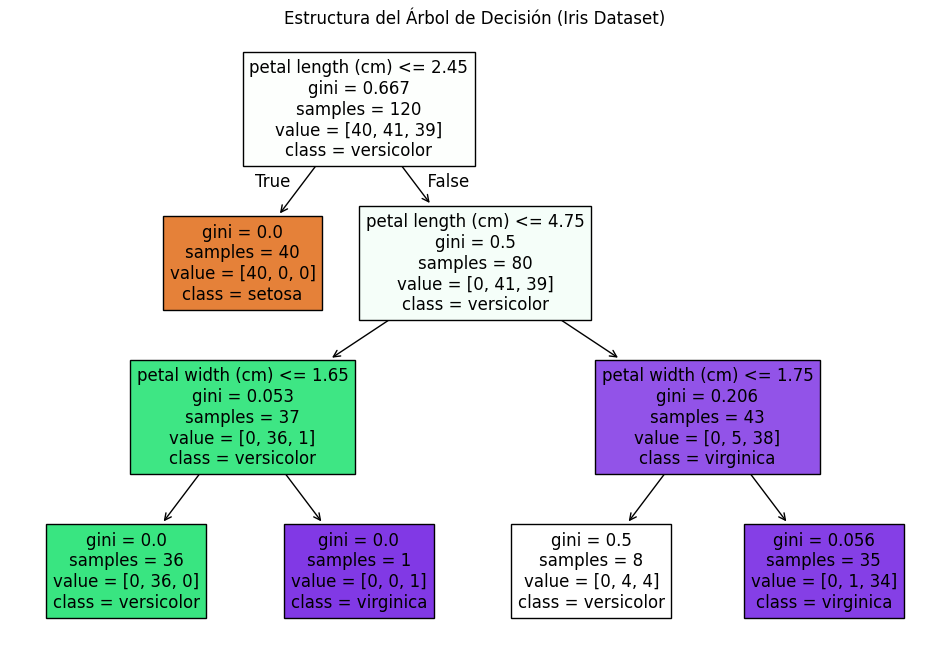

In [2]:
# =========================================================================
# IMPORTACIÓN DE LIBRERÍAS (Sintaxis y Propósito)
# =========================================================================

# Importamos 'pandas' para la manipulación y estructura de datos en tablas
import pandas as pd

# 'load_iris' es una función para cargar el dataset clásico de flores Iris
from sklearn.datasets import load_iris

# 'train_test_split' sirve para dividir los datos de forma aleatoria en entrenamiento y prueba
from sklearn.model_selection import train_test_split

# 'DecisionTreeClassifier' es la clase del algoritmo de Árbol de Decisión
# 'plot_tree' es la función que nos permite dibujar/renderizar la estructura del árbol
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 'matplotlib.pyplot' es la biblioteca estándar para crear gráficos en Python
import matplotlib.pyplot as plt

# =========================================================================
# 1. CARGA DE DATOS Y ASIGNACIÓN DE VARIABLES
# =========================================================================

# Llamamos a la función para almacenar el objeto que contiene el dataset completo en 'iris'
iris = load_iris()

# Asignamos a 'X' las variables predictoras (largo/ancho de sépalo y pétalo)
# Asignamos a 'y' la variable objetivo o etiquetas de clase (setosa, versicolor, virginica)
X, y = iris.data, iris.target

# =========================================================================
# 2. DIVISIÓN DEL DATASET (Lógica de Validación)
# =========================================================================

# X_train / y_train: datos para que el modelo aprenda patrones
# X_test / y_test: datos reservados para verificar si el modelo aprendió correctamente
# test_size=0.2: asigna el 20% de los datos para prueba y el 80% para entrenamiento
# random_state=42: semilla que asegura que la división sea idéntica cada vez que se ejecute
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# =========================================================================
# 3. INSTANCIACIÓN Y CONFIGURACIÓN DEL MODELO
# =========================================================================

# Inicializamos el clasificador asignándolo a la variable 'model'
# max_depth=3: limita el crecimiento del árbol a 3 niveles para evitar sobreajuste (overfitting)
# random_state=42: garantiza reproducibilidad en los puntos de corte aleatorios del árbol
model = DecisionTreeClassifier(max_depth=3, random_state=42)

# =========================================================================
# 4. ENTRENAMIENTO DEL MODELO
# =========================================================================

# El método '.fit()' ejecuta el algoritmo matemático para crear las preguntas/divisiones óptimas
# utilizando las características de entrenamiento (X_train) y sus respuestas reales (y_train)
model.fit(X_train, y_train)

# =========================================================================
# 5. EVALUACIÓN DE DESEMPEÑO
# =========================================================================

# '.score()' calcula la exactitud (accuracy) comparando las predicciones sobre X_test contra y_test
accuracy = model.score(X_test, y_test)

# Imprimimos el resultado formateado a porcentaje con dos decimales usando f-strings
print(f"Precisión del Árbol de Decisión: {accuracy:.2%}\n")

# =========================================================================
# 6. VISUALIZACIÓN GRÁFICA DEL ÁRBOL
# =========================================================================

# Creamos una figura en blanco para el lienzo del gráfico con tamaño de 12x8 pulgadas
fig = plt.figure(figsize=(12, 8))

# Dibujamos el árbol:
# - feature_names: coloca el nombre real de cada columna (ej. 'petal length') en los nodos
# - class_names: coloca el nombre de las especies de flor en las hojas terminales
# - filled=True: colorea los nodos según la clase mayoritaria y la pureza del nodo
plot_tree(model, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)

# Añadimos un título descriptivo en la parte superior del gráfico
plt.title("Estructura del Árbol de Decisión (Iris Dataset)")

# Desplegamos el lienzo final con todos los elementos renderizados
plt.show()

### ¿Cómo se hace un Árbol Aleatorio (Random Forest)?

Un **Árbol de Decisión** individual toma decisiones basadas en reglas óptimas para todo el conjunto. Un **Bosque Aleatorio (Random Forest)** es una técnica de *Ensemble* que entrena múltiples árboles de decisión de forma independiente mediante:
1. **Bootstrap (Muestreo aleatorio):** Cada árbol se entrena con una porción aleatoria de los datos.
2. **Selección aleatoria de características:** En cada división del árbol, solo se considera un subconjunto aleatorio de variables (por ejemplo, el largo del pétalo pero no el ancho).

Para implementarlo en Python, simplemente importamos `RandomForestClassifier` en lugar de `DecisionTreeClassifier`:

```python
from sklearn.ensemble import RandomForestClassifier

# Creamos un bosque con 100 árboles aleatorios
forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
forest_model.fit(X_train, y_train)
print(f"Precisión del Bosque Aleatorio: {forest_model.score(X_test, y_test):.2%}")
```